# 1. Navázání na DÚ1 (Task framing)

---

### **Business problém**
Tvůrci na Kickstarteru riskují značnou ztrátu času a finančních prostředků při spuštění nevhodně nastavené kampaně.
Cílem projektu je vytvořit **"pre-launch poradce"**. Ten tvůrci ještě před ostrým startem poskytne odhad šance na úspěch, což mu umožní včas optimalizovat klíčové parametry (např. realistické nastavení cílové částky).

### **Analytická specifikace**

*   **Analytická úloha:** Binární klasifikace.
    > Model nebude poskytovat pouze strohé rozhodnutí „uspěje/neuspěje“, ale **kalibrovanou pravděpodobnost úspěchu**. To je klíčové pro *cost-sensitive* rozhodování tvůrce.
*   **Jednotka pozorování:** Jedna konkrétní kampaň v čase těsně před jejím spuštěním (*pre-launch*).
*   **Cílová proměnná (Target):** Sloupec `state` (úspěch = **1** / neúspěch = **0**).

### **Hodnotící metriky**
Pro komplexní posouzení kvality modelu se zaměříme na:
1.  **F1-score:** Pro vyvážené zhodnocení přesnosti a pokrytí u pravděpodobně nevyváženého datasetu.
2.  **Brier score:** Pro měření kvality a přesnosti kalibrace předpovězených pravděpodobností.

**Priorita:** Minimalizace **False Positives** (falešná naděje na úspěch), které jsou pro tvůrce ekonomicky nejrizikovější.

---

## 2. Popis dat

---

### **Zdroj a rozsah**
Pracujeme s **plným originálním datasetem** z platformy **Kaggle** (*Kickstarter Projects*).

*   **Soubor:** `ks-projects-201801.csv`
*   **Rozsah:** Více než **300 000** historických kampaní.

### **Charakteristika dat**
Dataset je ve formátu **CSV** a poskytuje komplexní pohled na historii projektů skrze:
*   **Kategorizaci:** Detailní členění do kategorií a podkategorií.
*   **Finanční parametry:** Cílové částky (goal) a měny.
*   **Časové aspekty:** Časová razítka spuštění a konců kampaní, která jsou klíčová pro pochopení sezónnosti a délky trvání.

---

In [18]:
import pandas as pd

# 1. Stažení souboru přímo z tvého Google Drive do paměti Colabu
# Použijeme nástroj gdown a tvoje ID souboru z odkazu
!gdown --id 13fB4Z9aOL7gM8cNDwCZPvWbKj1Vllljo -O ks-projects-201801.csv

# 2. Načtení plného datasetu, který se právě stáhl
df = pd.read_csv('ks-projects-201801.csv')

# 3. Výpisy (s opraveným .shape[1] pro sloupce)
print("\n--- ZÁKLADNÍ INFORMACE O DATECH ---")
print(f"Počet řádků: {df.shape[0]}, Počet sloupců: {df.shape[1]}")
print(f"Počet duplicitních řádků: {df.duplicated().sum()}")

print("\n--- CHYBĚJÍCÍ HODNOTY ---")
chybejici = df.isnull().sum()[df.isnull().sum() > 0]
if chybejici.empty:
    print("Žádné chybějící hodnoty.")
else:
    print(chybejici)

# Základní popis targetu
print("\n--- ROZLOŽENÍ CÍLOVÉ PROMĚNNÉ 'state' ---")
print(df['state'].value_counts())

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13fB4Z9aOL7gM8cNDwCZPvWbKj1Vllljo
To: /content/ks-projects-201801.csv
100% 58.0M/58.0M [00:01<00:00, 57.3MB/s]

--- ZÁKLADNÍ INFORMACE O DATECH ---
Počet řádků: 378661, Počet sloupců: 15
Počet duplicitních řádků: 0

--- CHYBĚJÍCÍ HODNOTY ---
name              4
usd pledged    3797
dtype: int64

--- ROZLOŽENÍ CÍLOVÉ PROMĚNNÉ 'state' ---
state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64


## 3. Leakage audit & Čištění dat

---

### **1. Identifikace a prevence Data Leakage**
Největším rizikem tohoto projektu je **data leakage** (únik informací z budoucnosti). Aby byl model v praxi použitelný pro predikci *před* spuštěním projektu, musí pracovat striktně s daty dostupnými v čase **pre-launch**.

*   **Rizikové proměnné (Leakage):** Sloupce `pledged`, `usd pledged`, `usd_pledged_real` a `backers`.
*   **Důvod:** Tyto hodnoty vznikají až v průběhu kampaně. Například počet přispěvatelů (`backers`) přímo určuje úspěch – pokud bychom ho v datech nechali, model by se nenaučil predikovat úspěch, ale pouze "odečítat" výsledek z průběžných statistik.
*   **Řešení:** Všechny výše zmíněné sloupce byly z datasetu před trénováním **odstraněny**.

### **2. Příprava na modelování a redukce šumu**
Aby byl model stabilní a zaměřený na relevantní data, provedli jsme následující kroky:
*   **Filtrace cílové proměnné:** Omezujeme se pouze na stavy `successful` a `failed`. Ostatní (např. *canceled* nebo *live*) do binární klasifikace nepatří.
*   **Targeting:** Textová data převádíme na binární číselnou reprezentaci (**1 = úspěch**, **0 = neúspěch**).
*   **Odstranění outlierů:** Odfiltrujeme extrémní anomálie v cílových částkách (projekty s nereálnými cíli nad 100 mil. USD), které by vnášely do modelu zbytečný šum.

### **3. Vizuální ověření (Sanity Check)**
Před samotným čištěním graficky ověřujeme:
1.  **Korelaci Backers a Success:** Potvrzení, že počet přispěvatelů je skutečně "leakage" proměnná.
2.  **Distribuci cílových částek:** Identifikace extrémních hodnot, které deformují měřítko dat.

---

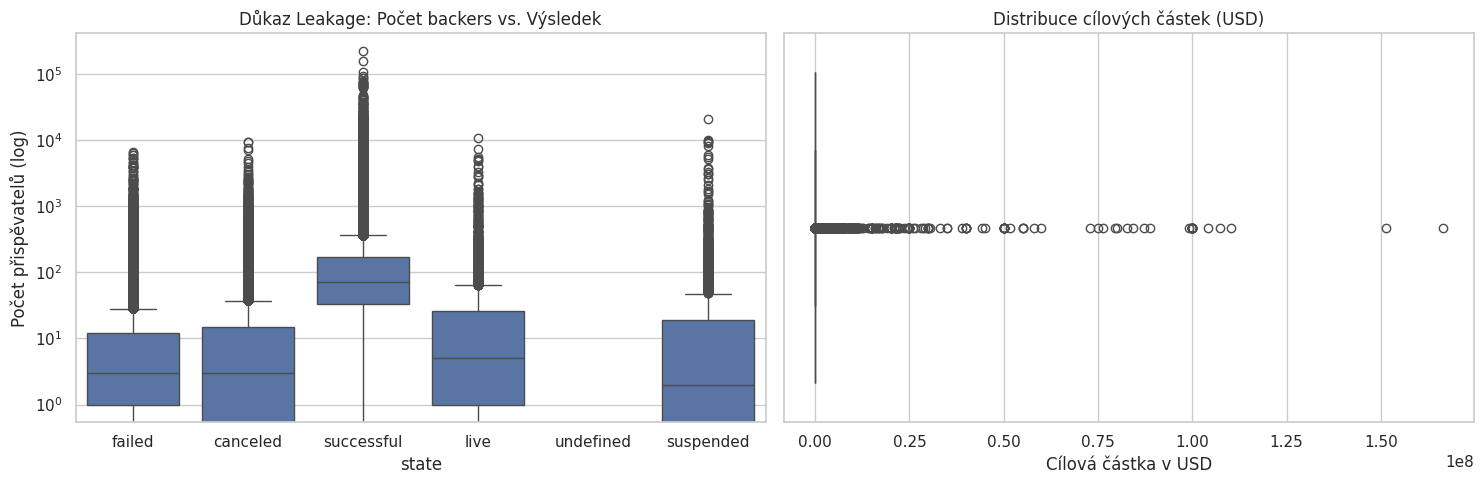

Max. cílová částka v datech: 166,361,391 USD
Průměrná cílová částka: 45,454 USD


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavení stylu
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Graf 1: Proč je 'backers' leakage?
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='state', y='backers')
plt.title('Důkaz Leakage: Počet backers vs. Výsledek')
plt.yscale('log') # Logaritmická škála, aby byly vidět rozdíly
plt.ylabel('Počet přispěvatelů (log)')

# Graf 2: Proč musíme filtrovat Outliery v cílové částce?
plt.subplot(1, 2, 2)
sns.boxplot(x=df['usd_goal_real'])
plt.title('Distribuce cílových částek (USD)')
plt.xlabel('Cílová částka v USD')

plt.tight_layout()
plt.show()

# Výpis extrémních hodnot pro kontext
print(f"Max. cílová částka v datech: {df['usd_goal_real'].max():,.0f} USD")
print(f"Průměrná cílová částka: {df['usd_goal_real'].mean():,.0f} USD")

In [20]:
# --- 1. FILTRACE A ZÁKLADNÍ ČIŠTĚNÍ ---
# Ponecháme jen dokončené kampaně a odstraníme extrémní anomálie
df_clean = df[df['state'].isin(['successful', 'failed'])].copy()
df_clean = df_clean[df_clean['usd_goal_real'] <= 100000000]

# --- 2. ODSTRANĚNÍ LEAKAGE ---
# Tyto sloupce model nesmí vidět, protože vznikají až v průběhu kampaně
leakage_cols = ['pledged', 'usd pledged', 'usd_pledged_real', 'backers']
df_clean = df_clean.drop(columns=leakage_cols, errors='ignore')

# --- 3. REDUKCE VELIKOSTI (ZEŠTÍHLENÍ PRO GITHUB) ---
# Sloupce ID a Name jsou pro tabulkový model zbytečné a soubor extrémně nafukují
# Smažeme také redundantní měny, když máme 'usd_goal_real'
size_reduction_cols = ['ID', 'name', 'currency', 'goal', 'pledged']
df_clean = df_clean.drop(columns=[c for c in size_reduction_cols if c in df_clean.columns], errors='ignore')

# --- 4. VYTVOŘENÍ TARGETU ---
df_clean['target'] = (df_clean['state'] == 'successful').astype(int)
df_clean = df_clean.drop(columns=['state'])

print("--- ČIŠTĚNÍ A LEAKAGE AUDIT HOTOVO ---")
print(f"Aktuální počet řádků: {df_clean.shape[0]}")
print(f"Sloupce zůstávající pro model: {df_clean.columns.tolist()}")
print(f"\nRozdělení targetu:\n{df_clean['target'].value_counts(normalize=True).round(2)}")

--- ČIŠTĚNÍ A LEAKAGE AUDIT HOTOVO ---
Aktuální počet řádků: 331670
Sloupce zůstávající pro model: ['category', 'main_category', 'deadline', 'launched', 'country', 'usd_goal_real', 'target']

Rozdělení targetu:
target
0    0.6
1    0.4
Name: proportion, dtype: float64


## 4. Návrh splitu & 5. Vytvoření sad

---

### **Časový split (Time-based Split)**
Jelikož platforma Kickstarter prochází v čase neustálým vývojem (změny chování uživatelů, globální ekonomiky i pravidel platformy), **náhodné rozdělení dat by bylo chybou**. Způsobilo by tzv. *data leakage v čase* (model by viděl budoucnost při predikci minulosti).

*   **Strategie:** Data řadíme chronologicky podle data spuštění (`launched`).
*   **Cíl:** Model musí prokázat schopnost generalizovat na projekty, které přišly až po datech, na kterých se učil. Tím se bráníme proti **concept driftu**.
*   **Poměr rozdělení:**
    *   **Train (70 %):** Historická data pro učení.
    *   **Validation (15 %):** Ladění hyperparametrů.
    *   **Test (15 %):** Finální simulace nasazení na "budoucích" datech.

---

In [21]:
import os

# 1. Převedení na datetime a seřazení chronologicky
df_clean['launched'] = pd.to_datetime(df_clean['launched'])
df_clean['deadline'] = pd.to_datetime(df_clean['deadline'])
df_clean = df_clean.sort_values(by='launched').reset_index(drop=True)

# 2. Definice indexů pro rozdělení (70% train, 15% val, 15% test)
train_idx = int(len(df_clean) * 0.70)
val_idx = int(len(df_clean) * 0.85)

# 3. Vytvoření sad
df_train = df_clean.iloc[:train_idx].copy()
df_val = df_clean.iloc[train_idx:val_idx].copy()
df_test = df_clean.iloc[val_idx:].copy()

print("--- ROZDĚLENÍ DOKONČENO ---")
print(f"Train: {len(df_train)} řádků | Val: {len(df_val)} | Test: {len(df_test)}")

# 4. Uložení sad do složky 'data'
os.makedirs('data', exist_ok=True)

datasets = {
    'data/train.csv': df_train,
    'data/validation.csv': df_val,
    'data/test.csv': df_test
}

for path, data in datasets.items():
    # index=False je důležité pro úsporu místa
    data.to_csv(path, index=False)

    # KONTROLA VELIKOSTI SOUBORU
    size_mb = os.path.getsize(path) / (1024 * 1024)
    status = "✅ OK (pod 25MB)" if size_mb < 25 else "❌ PŘÍLIŠ VELKÉ"
    print(f"Soubor {path}: {size_mb:.2f} MB {status}")

--- ROZDĚLENÍ DOKONČENO ---
Train: 232168 řádků | Val: 49751 | Test: 49751
Soubor data/train.csv: 13.70 MB ✅ OK (pod 25MB)
Soubor data/validation.csv: 2.95 MB ✅ OK (pod 25MB)
Soubor data/test.csv: 2.95 MB ✅ OK (pod 25MB)


## 6. Preprocessing Pipeline

---

### **Vytvoření nových příznaků (Feature Engineering)**
Z dostupných časových údajů (`launched` a `deadline`) odvozujeme novou proměnnou **`duration_days`**. Tato proměnná vyjadřuje délku kampaně ve dnech, což je klíčový parametr, který tvůrce může před spuštěním ovlivnit.

### **Příprava transformační roury (Pipeline)**
Pro finální přípravu dat před trénováním využíváme `ColumnTransformer`:
*   **Numerické proměnné:** Aplikujeme `StandardScaler` pro normalizaci rozsahů (důležité pro modely jako Logistická regrese nebo SVM).
*   **Kategorické proměnné:** Používáme `OneHotEncoder` s nastavením `handle_unknown='ignore'`, abychom zajistili stabilitu modelu v případě, že se v testovacích datech objeví nová, dosud neviděná kategorie.

### **Zlaté pravidlo: Prevence Preprocessing Leakage**
> **Kritický krok:** Celý preprocesor (výpočet průměrů, směrodatných odchylek a mapování kategorií) je **fitován (učen) výhradně na trénovací sadě (`df_train`)**. Transformační parametry jsou následně pouze aplikovány na validační a testovací sadu. Tím zabraňujeme úniku informací z budoucnosti do trénovacího procesu.

---

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# 1. Feature engineering: Odvození délky kampaně
def add_features(data):
    d = data.copy()
    # Sloupce 'deadline' a 'launched' už máme jako datetime z předchozího kroku
    d['duration_days'] = (d['deadline'] - d['launched']).dt.days
    return d

X_train_full = add_features(df_train)
X_val_full = add_features(df_val)
X_test_full = add_features(df_test)

# 2. Definice pre-launch featur a targetu
num_cols = ['usd_goal_real', 'duration_days']
cat_cols = ['main_category', 'country']
features = num_cols + cat_cols

y_train = X_train_full['target']
X_train = X_train_full[features]

y_val = X_val_full['target']
X_val = X_val_full[features]

y_test = X_test_full['target']
X_test = X_test_full[features]

# 3. Nastavení preprocessoru
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 4. ZLATÉ PRAVIDLO: Fit POUZE na train sadě
preprocessor.fit(X_train)

# 5. Transformace všech sad
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Kontrolní výpis
print("--- PREPROCESSING DOKONČEN ---")
print(f"Původní počet featur: {len(features)}")
print(f"Počet featur po One-Hot kódování: {X_train_processed.shape[1]}")
print(f"Tvar výsledné matice (train): {X_train_processed.shape}")

# Bonus: Ukázka názvů featur (pro kontrolu, co OHE vytvořil)
feature_names = preprocessor.get_feature_names_out()
print("\nUkázka prvních 10 transformovaných sloupců:")
print(feature_names[:10])

--- PREPROCESSING DOKONČEN ---
Původní počet featur: 4
Počet featur po One-Hot kódování: 36
Tvar výsledné matice (train): (232168, 36)

Ukázka prvních 10 transformovaných sloupců:
['num__usd_goal_real' 'num__duration_days' 'cat__main_category_Art'
 'cat__main_category_Comics' 'cat__main_category_Crafts'
 'cat__main_category_Dance' 'cat__main_category_Design'
 'cat__main_category_Fashion' 'cat__main_category_Film & Video'
 'cat__main_category_Food']
